# Study Case 1 - NLP

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, recall_score

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

!pip install contractions
import contractions
import pandas as pd
import spacy
import re
import string
"done"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 6.8 MB/s eta 0:00:00


'done'

In [ ]:
url = 'https://raw.githubusercontent.com/wal-03/NLP-2025/refs/heads/main/Dataset%20UTS%20NLP/train.csv'
try:
    df = pd.read_csv(url, low_memory=False, encoding='utf8')
except Exception as e:
    print(f"Error loading or processing data: {e}")
    raise
df

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


##EDA

In [ ]:
df[df['keyword']=='ablaze']

,id,keyword,location,text,target
31,48,ablaze,Birmingham,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1
32,49,ablaze,Est. September 2012 - Bristol,We always try to bring the heavy. #metal #RT h...,0
33,50,ablaze,AFRICA,#AFRICANBAZE: Breaking news:Nigeria flag set a...,1
34,52,ablaze,"Philadelphia, PA",Crying out for more! Set me ablaze,0
35,53,ablaze,"London, UK",On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0
36,54,ablaze,Pretoria,@PhDSquares #mufc they've built so much hype a...,0
37,55,ablaze,World Wide!!,INEC Office in Abia Set Ablaze - http://t.co/3...,1
38,56,ablaze,NaN,Barbados #Bridgetown JAMAICA ÛÒ Two cars set ...,1
39,57,ablaze,Paranaque City,Ablaze for you Lord :D,0
40,59,ablaze,Live On Webcam,Check these out: http://t.co/rOI2NSmEJJ http:/...,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [ ]:
df.isnull().sum()

,0
id,0
keyword,61
location,2533
text,0
target,0


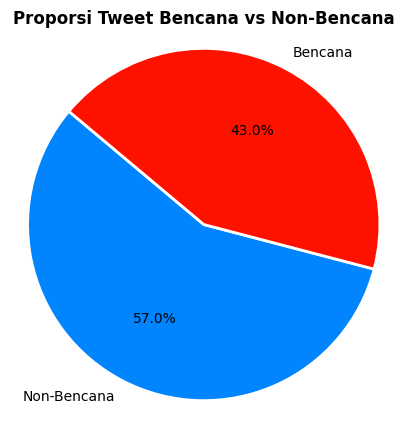

In [ ]:
counts = df['target'].value_counts().sort_index()
labels = ['Non-Bencana', 'Bencana']
colors = ['#0085ff', '#ff1100']

plt.figure(figsize=(5, 5))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # garis putih sebagai pemisah
)
plt.title('Proporsi Tweet Bencana vs Non-Bencana',fontweight='bold')
plt.axis('equal')  # membuat pie jadi bulat
plt.show()


In [ ]:
# df[df['target']==0].sample(10)
df[df['target']==1].sample(10)

,id,keyword,location,text,target
1959,2821,cyclone,Philippines,SEVERE WEATHER BULLETIN No. 5\nFOR: TYPHOON Û...,1
2767,3977,devastation,Brasil,70 Years After Atomic Bombs Japan Still Strugg...,1
3350,4795,evacuated,Breaking News,Evacuation order lifted for town of Roosevelt ...,1
4452,6335,hostages,THANJAVUR,2 hostages in Libya remain unharmed: Governmen...,1
6055,8654,sinkhole,NY,Gaping sinkhole opens up in Brooklyn New York ...,1
1734,2498,collided,Hertfordshire,Well that was a journey to get home! A train c...,1
6412,9169,suicide%20bomber,Indonesia,Suicide bomber kills 15 in Saudi security site...,1
4837,6884,mass%20murder,"Fiore, Lamia Scale",@Re_ShrimpLevy I'm always up for mass murder,1
3785,5377,fire%20truck,NaN,Former Township fire truck being used in Phili...,1
5881,8400,sandstorm,USA,Watch This Airport Get Swallowed Up By A Sands...,1


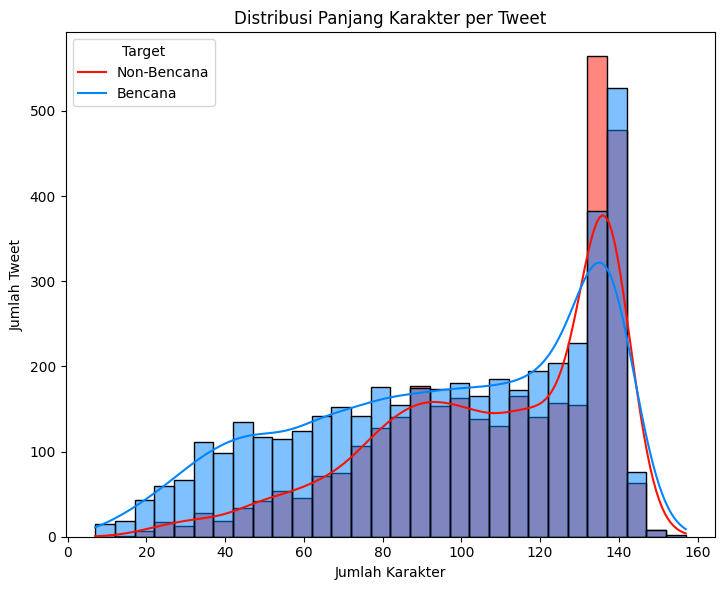

In [ ]:
# Analisis panjang teks tweet
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='char_count', hue='target', kde=True, bins=30,
             palette={0: '#0085ff', 1: '#ff1100'})  # biru untuk 0, merah untuk 1
plt.title('Distribusi Panjang Karakter per Tweet')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Jumlah Tweet')
plt.legend(title='Target', labels=['Non-Bencana', 'Bencana'])

plt.tight_layout()
plt.show()

/tmp/ipython-input-9-860731193.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


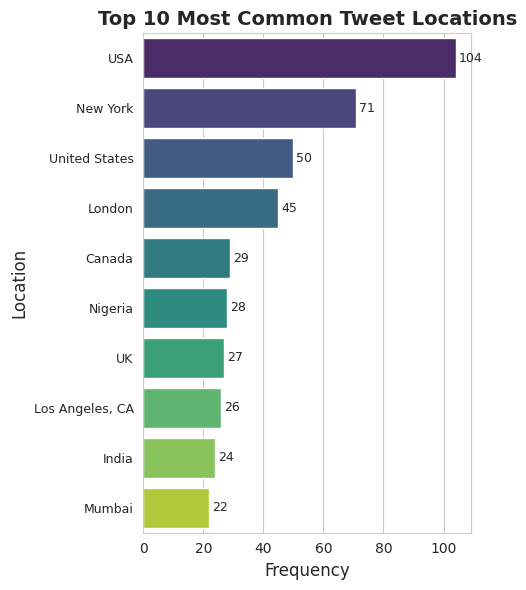

In [ ]:
# Ambil 50 lokasi teratas
top_locations = df['location'].value_counts().head(10)

# Set gaya visualisasi
sns.set_style("whitegrid")
plt.figure(figsize=(5,6))

# Buat horizontal barplot
barplot = sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    palette="viridis"
)

# Tambahkan label angka di ujung batang
for i, value in enumerate(top_locations.values):
    plt.text(value + 1, i, str(value), va='center', fontsize=9)

# Judul dan label
plt.title('Top 10 Most Common Tweet Locations', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## Preprocessing

In [ ]:
# Muat model spaCy (pastikan sudah install: python -m spacy download en_core_web_sm)
nlp = spacy.load("en_core_web_sm")

# Custom stopwords tambahan dari kamu
custom_stop_words = {'u', 'going', 'youre', 'im', 'amp', 'get', 'like', 'dont', 'thats', 'one', 'http', 'co'}

def clean_text_terbaik(text):
    """
    Membersihkan teks: lowercase, hapus noise, lemmatization, dan hapus stopwords.
    Menggunakan stopwords bawaan spaCy + custom stopwords.
    """
    # Langkah cleaning dasar
    text = text.lower()
    text = contractions.fix(text)  # Expand contractions
    text = re.sub(r'https?://\S+|www\.\S+', '', text)     # Hapus URL
    text = re.sub(r'<.*?>+', '', text)                    # Hapus tag HTML
    text = re.sub(r'\[.*?\]', '', text)                   # Hapus teks dalam kurung siku
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # Hapus tanda baca
    text = re.sub(r'\n', ' ', text)                       # Ganti newline
    text = re.sub(r'\w*\d\w*', '', text)                  # Hapus kata berangka
    text = re.sub(r'[^\x00-\x7f]', r'', text)             # Hapus karakter non-ASCII (emoji, simbol asing)

    # Proses NLP spaCy
    doc = nlp(text)
    cleaned_tokens = [
        token.lemma_ for token in doc
        if not token.is_stop                             # Stopword dari spaCy
        and token.lemma_ not in custom_stop_words        # Tambahan custom stopword
        and not token.is_punct
        and not token.is_space
        and len(token.lemma_) > 1                        # Hindari kata satu huruf
    ]

    return " ".join(cleaned_tokens).strip()
df['cleaned_text'] = df['text'].apply(clean_text_terbaik)

In [ ]:
print("\nContoh Teks Sebelum dan Sesudah Preprocessing:\n")
print("Original  :", df['text'].iloc[43])
print("Cleaned   :", df['cleaned_text'].iloc[43])
print("\nOriginal  :", df['text'].iloc[51])
print("Cleaned   :", df['cleaned_text'].iloc[51])


Contoh Teks Sebelum dan Sesudah Preprocessing:

Original  : SOOOO PUMPED FOR ABLAZE ???? @southridgelife
Cleaned   : soooo pump ablaze southridgelife

Original  : Man wife get six years jail for setting ablaze niece
http://t.co/eV1ahOUCZA
Cleaned   : man wife year jail set ablaze niece


###Top 20 word

/tmp/ipython-input-12-3822245977.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=df_top_non_disaster, palette='viridis')
/tmp/ipython-input-12-3822245977.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=df_top_disaster, palette='plasma')


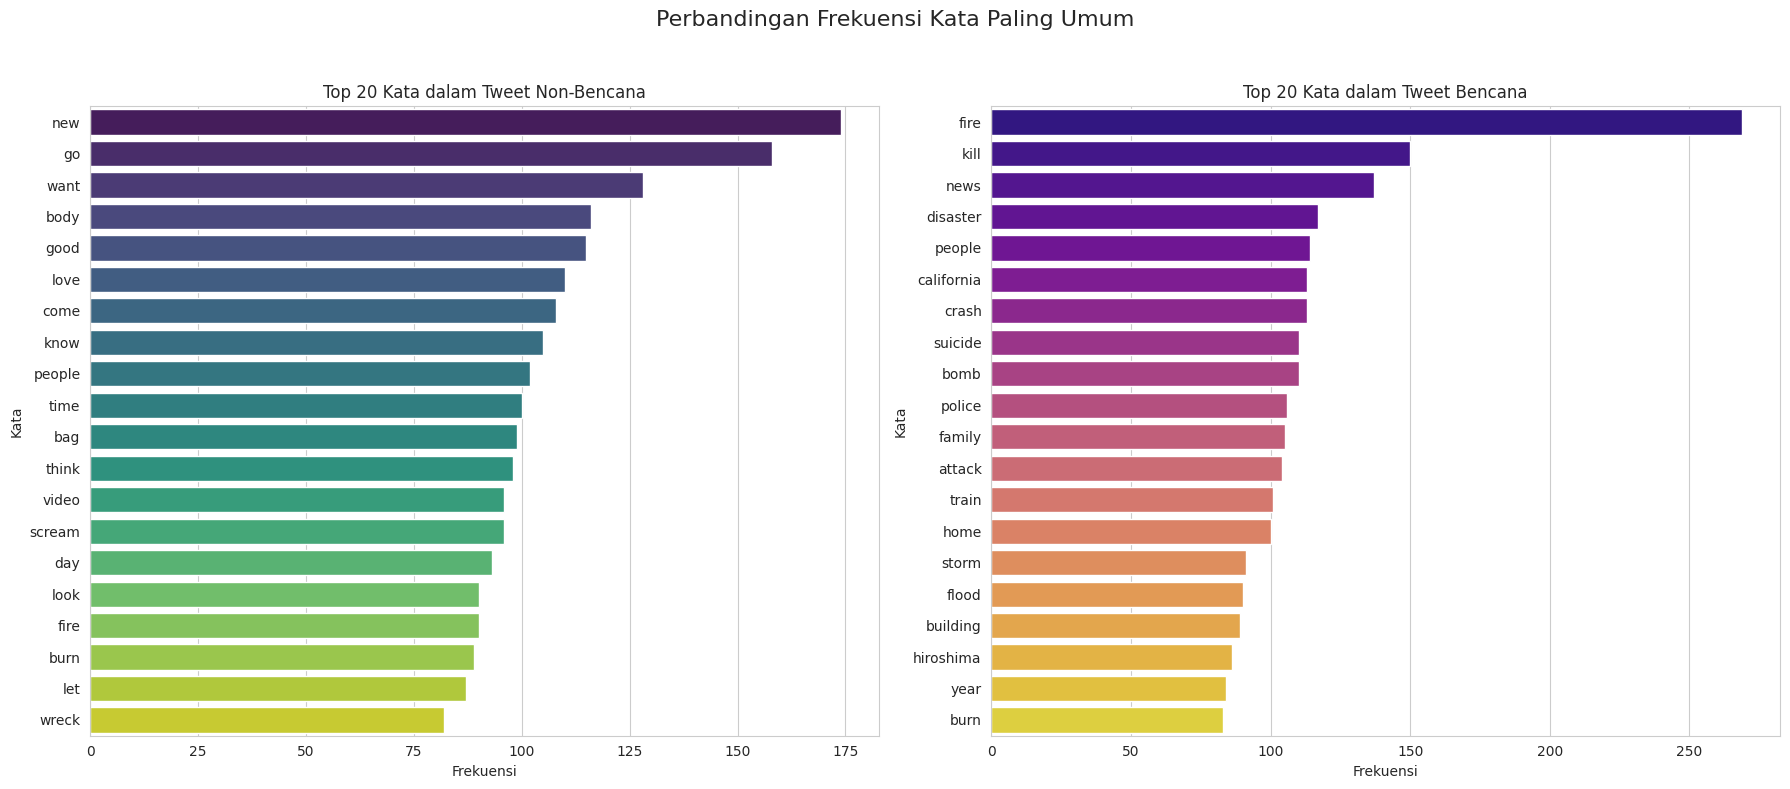

In [ ]:
from collections import Counter
def get_top_n_words(corpus, n=None):
    """
    Fungsi untuk mendapatkan n kata paling umum dari sebuah corpus teks.
    """
    # Gabungkan semua tweet menjadi satu string besar, lalu pisahkan menjadi kata-kata
    all_words = " ".join(text for text in corpus).split()

    # Hitung frekuensi setiap kata
    word_counts = Counter(all_words)

    # Dapatkan n kata paling umum
    top_words = word_counts.most_common(n)

    return top_words

# Dapatkan corpus untuk masing-masing kategori dari kolom yang sudah bersih
corpus_disaster = df[df['target'] == 1]['cleaned_text']
corpus_non_disaster = df[df['target'] == 0]['cleaned_text']

# Dapatkan 20 kata teratas untuk setiap kategori
top_20_disaster_words = get_top_n_words(corpus_disaster, n=20)
top_20_non_disaster_words = get_top_n_words(corpus_non_disaster, n=20)

# Ubah hasil menjadi DataFrame untuk visualisasi yang mudah
df_top_disaster = pd.DataFrame(top_20_disaster_words, columns=['Kata', 'Frekuensi'])
df_top_non_disaster = pd.DataFrame(top_20_non_disaster_words, columns=['Kata', 'Frekuensi'])

# Buat plot
plt.figure(figsize=(18, 8))

# Plot untuk tweet Non-Bencana
plt.subplot(1, 2, 1)
sns.barplot(x='Frekuensi', y='Kata', data=df_top_non_disaster, palette='viridis')
plt.title('Top 20 Kata dalam Tweet Non-Bencana')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')

# Plot untuk tweet Bencana
plt.subplot(1, 2, 2)
sns.barplot(x='Frekuensi', y='Kata', data=df_top_disaster, palette='plasma')
plt.title('Top 20 Kata dalam Tweet Bencana')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')

plt.suptitle('Perbandingan Frekuensi Kata Paling Umum', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

In [ ]:
df

,id,keyword,location,text,target,char_count,word_count,cleaned_text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,69,13,deed reason earthquake allah forgive
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38,7,forest fire near la ronge sask canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,133,22,resident ask shelter place notify officer evac...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,65,8,people receive wildfire evacuation order calif...
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,88,16,send photo ruby alaska smoke wildfire pour school
...,...,...,...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1,83,11,giant crane hold bridge collapse nearby home
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1,125,20,ariaahrary thetawniest control wild fire calif...
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1,65,8,volcano hawaii
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1,137,19,police investigate ebike collide car little po...


## Logistic Regression

###TF-IDF

In [ ]:
# Text data
texts = df['cleaned_text']

# Parameter grid khusus untuk TfidfVectorizer
param_grid = {
    'ngram_range': [(1, 1), (1, 2)],
    'max_df': [0.75, 0.9, 1.0],
    'min_df': [1, 2, 5],
    'max_features': [1000, 3000, 5000],
    'sublinear_tf': [True, False],
    'stop_words': [None, 'english']
}

# Untuk menyimpan hasil evaluasi
results = []

# Coba semua kombinasi parameter
for params in ParameterGrid(param_grid):
    try:
        vectorizer = TfidfVectorizer(**params)
        X_tfidf = vectorizer.fit_transform(texts)

        results.append({
            'params': params,
            'n_features': X_tfidf.shape[1],
            'avg_doc_length': X_tfidf.sum(axis=1).mean()
        })
    except Exception as e:
        results.append({
            'params': params,
            'n_features': 'error',
            'avg_doc_length': 'error'
        })

# Konversi ke DataFrame untuk analisis
tfidf_results_df = pd.DataFrame(results)

In [ ]:
best_row = tfidf_results_df.sort_values(by='n_features', ascending=False).iloc[0]
best_params = best_row['params']

In [ ]:
print("Parameter paling stabil:", best_params)

Parameter paling stabil: {'max_df': 0.75, 'max_features': 5000, 'min_df': 1, 'ngram_range': (1, 2), 'stop_words': 'english', 'sublinear_tf': False}


In [ ]:
tfidf_lr = TfidfVectorizer(**best_params)
X_tfidf_lr = tfidf_lr.fit_transform(df['cleaned_text'])

# y: label target (bencana atau tidak)
y = df['target']

###Feature Selection & Split Data

In [ ]:
# For Logistic Regression (k=3000 features)
selector_lr = SelectKBest(chi2, k=3000)
X_selected_lr = selector_lr.fit_transform(X_tfidf_lr, y) # Use X and y from LR TF-IDF section
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_selected_lr, y, test_size=0.2, random_state=12, stratify=y)

###Base Model

In [ ]:
model_lr = LogisticRegression(random_state=42, C=1.0) # C adalah parameter regularisasi
model_lr.fit(X_train_lr, y_train_lr)

LogisticRegression(random_state=42)

In [ ]:
# Fungsi untuk menampilkan hasil evaluasi
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n--- Evaluasi untuk {model_name} ---\n")
    y_pred = model.predict(X_test)

    # Metrik
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")


    # Laporan Klasifikasi
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Bencana', 'Bencana']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Prediksi Non-Bencana', 'Prediksi Bencana'],
                yticklabels=['Aktual Non-Bencana', 'Aktual Bencana'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Label Aktual')
    plt.xlabel('Label Prediksi')
    plt.show()


--- Evaluasi untuk Logistic Regression ---

Accuracy: 0.8253
Precision: 0.8579
Recall: 0.7110
F1-Score: 0.7776

Classification Report:
              precision    recall  f1-score   support

 Non-Bencana       0.81      0.91      0.86       869
     Bencana       0.86      0.71      0.78       654

    accuracy                           0.83      1523
   macro avg       0.83      0.81      0.82      1523
weighted avg       0.83      0.83      0.82      1523



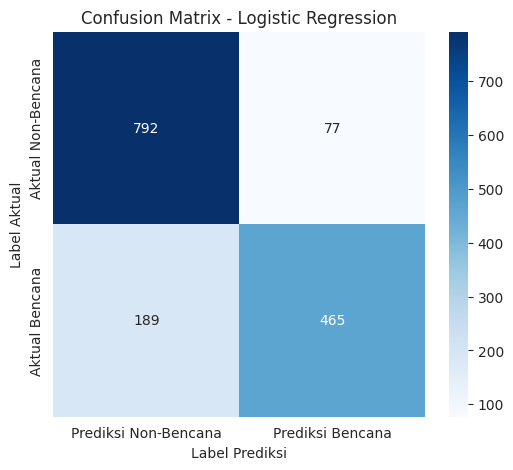

In [ ]:
evaluate_model(model_lr, X_test_lr, y_test_lr, "Logistic Regression")

###Parameter grid

In [ ]:
# Parameter grid untuk Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10, 50],     # Regularisasi
    'penalty': ['l2'],               # hanya l2 didukung oleh solver liblinear
    'solver': ['liblinear'],         # cocok untuk dataset kecil/sparse
    'class_weight': [None, 'balanced'],
    'max_iter': [100, 200, 500]
}

# Custom scoring hanya untuk kelas 1 (bencana)
f1_bencana = make_scorer(f1_score, pos_label=1)

###Cross Validation Strategy (Stratified K-Fold)

In [ ]:
# Gunakan StratifiedKFold untuk menjaga distribusi label
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

###Model Training

In [ ]:
grid_f1 = GridSearchCV(
    estimator=LogisticRegression(random_state=37),
    param_grid=param_grid,
    scoring=f1_bencana,
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

grid_f1.fit(X_train_lr, y_train_lr)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(random_state=37), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 50],
                         'class_weight': [None, 'balanced'],
                         'max_iter': [100, 200, 500], 'penalty': ['l2'],
                         'solver': ['liblinear']},
             scoring=make_scorer(f1_score, response_method='predict', pos_label=1),
             verbose=1)

###Evaluation

=== PARAMETER TERBAIK (GridSearchCV - F1 class 1) ===
{'C': 10, 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1 Score (class 1) dari CV: 0.7803

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

 Non-Bencana       0.85      0.85      0.85       869
     Bencana       0.80      0.80      0.80       654

    accuracy                           0.83      1523
   macro avg       0.83      0.83      0.83      1523
weighted avg       0.83      0.83      0.83      1523



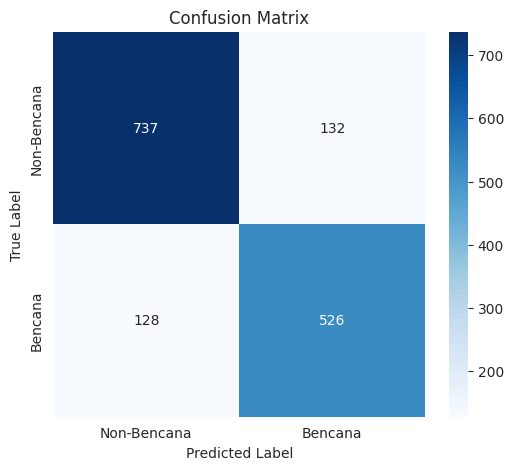

In [ ]:
# 1. Model terbaik hasil GridSearch
best_model_lr = grid_f1.best_estimator_

# 2. Parameter terbaik
print("=== PARAMETER TERBAIK (GridSearchCV - F1 class 1) ===")
print(grid_f1.best_params_)

# 3. Skor terbaik dari cross-validation
print(f"Best F1 Score (class 1) dari CV: {grid_f1.best_score_:.4f}")

# 4. Evaluasi pada Test Set
y_pred_lr = best_model_lr.predict(X_test_lr)

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test_lr, y_pred_lr, target_names=["Non-Bencana", "Bencana"]))

# 5. Confusion Matrix
cm_f1 = confusion_matrix(y_test_lr, y_pred_lr)
disp_f1 = ConfusionMatrixDisplay(confusion_matrix=cm_f1, display_labels=["Non-Bencana", "Bencana"])

plt.figure(figsize=(6,5))
sns.heatmap(cm_f1, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Bencana", "Bencana"],
            yticklabels=["Non-Bencana", "Bencana"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

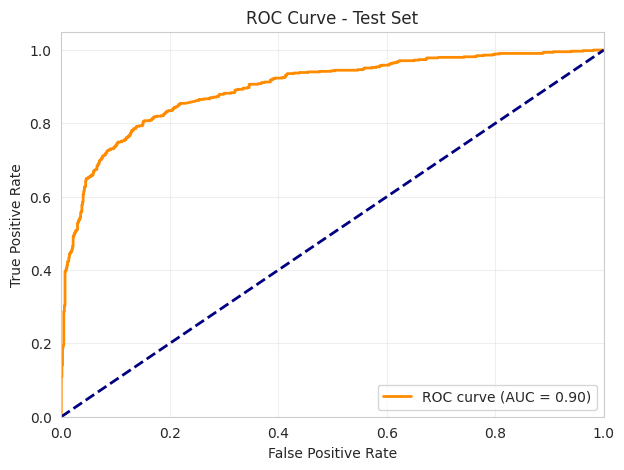

In [ ]:
# ROC Curve & AUC
y_pred_proba = best_model_lr.predict_proba(X_test_lr)[:, 1]  # Probabilitas kelas 1 (Bencana)

fpr, tpr, thresholds = roc_curve(y_test_lr, y_pred_proba)
auc_score = roc_auc_score(y_test_lr, y_pred_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Naive Bayes

###TF-IDF

In [ ]:
# TF-IDF vectorizer dengan parameter optimal
tfidf_nb = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=2,
    max_features=7000,
    sublinear_tf=True,
    stop_words='english'
)
X_tfidf_nb = tfidf_nb.fit_transform(df['cleaned_text'])
y = df['target']

###Feature Selection & Split Data

In [ ]:
# For Naive Bayes (k=5000 features)
selector_nb = SelectKBest(chi2, k=5000)
X_selected_nb = selector_nb.fit_transform(X_tfidf_nb, y) # Use X_tfidf and y from NB TF-IDF section
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_selected_nb, y, test_size=0.2, random_state=42, stratify=y)

###Base Model

In [ ]:
model_nb = MultinomialNB(alpha=1.0) # alpha adalah parameter smoothing
model_nb.fit(X_train_nb, y_train_nb)

MultinomialNB()


--- Evaluasi untuk Multinomial Naive Bayes ---

Accuracy: 0.8391
Precision: 0.8940
Recall: 0.7095
F1-Score: 0.7911

Classification Report:
              precision    recall  f1-score   support

 Non-Bencana       0.81      0.94      0.87       869
     Bencana       0.89      0.71      0.79       654

    accuracy                           0.84      1523
   macro avg       0.85      0.82      0.83      1523
weighted avg       0.85      0.84      0.84      1523



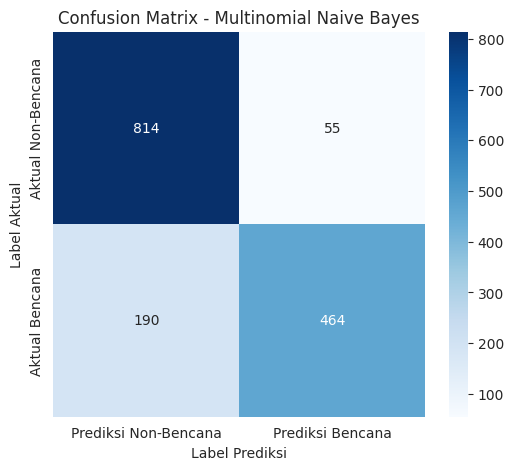

In [ ]:
evaluate_model(model_nb, X_test_nb, y_test_nb, "Multinomial Naive Bayes")

###Parameter Grid

In [ ]:
# Custom scorer untuk F1 class 1 (bencana)
f1_bencana = make_scorer(f1_score, pos_label=1)

# Parameter grid untuk Naive Bayes
param_grid_nb = [
    {
        'alpha': [0.001, 0.01, 0.1, 0.5, 1.0],
        'fit_prior': [True],
        'class_prior': [[0.4, 0.6], [0.45, 0.55], [0.5, 0.5]]
    },
    {
        'alpha': [0.001, 0.01, 0.1, 0.5, 1.0],
        'fit_prior': [False]
    }
]

###Model Training

In [ ]:
# Grid search
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_f1_nb = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=param_grid_nb,
    scoring=f1_bencana,
    cv=cv_strategy,
    verbose=1,
    n_jobs=-1
)
grid_f1_nb.fit(X_train_nb, y_train_nb)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=MultinomialNB(), n_jobs=-1,
             param_grid=[{'alpha': [0.001, 0.01, 0.1, 0.5, 1.0],
                          'class_prior': [[0.4, 0.6], [0.45, 0.55], [0.5, 0.5]],
                          'fit_prior': [True]},
                         {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0],
                          'fit_prior': [False]}],
             scoring=make_scorer(f1_score, response_method='predict', pos_label=1),
             verbose=1)

###Evaluation

=== PARAMETER TERBAIK (Naive Bayes - F1 class 1) ===
{'alpha': 0.01, 'class_prior': [0.5, 0.5], 'fit_prior': True}
Best CV F1 Score (class 1): 0.8001

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

 Non-Bencana       0.85      0.90      0.87       869
     Bencana       0.85      0.80      0.82       654

    accuracy                           0.85      1523
   macro avg       0.85      0.85      0.85      1523
weighted avg       0.85      0.85      0.85      1523



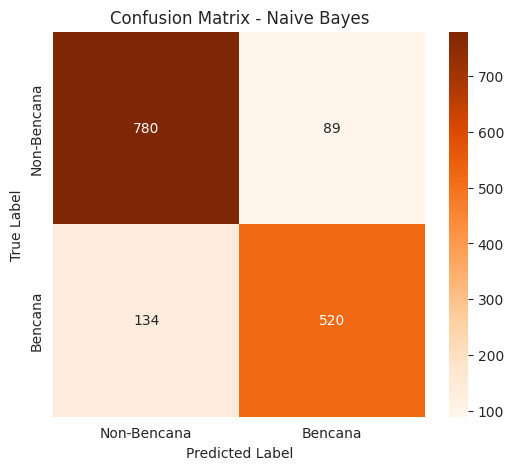

In [ ]:
# Evaluasi hasil
best_nb_model = grid_f1_nb.best_estimator_
y_pred_nb = best_nb_model.predict(X_test_nb)

print("=== PARAMETER TERBAIK (Naive Bayes - F1 class 1) ===")
print(grid_f1_nb.best_params_)
print(f"Best CV F1 Score (class 1): {grid_f1_nb.best_score_:.4f}\n")

print("=== Classification Report (Test Set) ===")
print(classification_report(y_test_nb, y_pred_nb, target_names=["Non-Bencana", "Bencana"]))

cm = confusion_matrix(y_test_nb, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Bencana", "Bencana"])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Non-Bencana", "Bencana"],
            yticklabels=["Non-Bencana", "Bencana"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

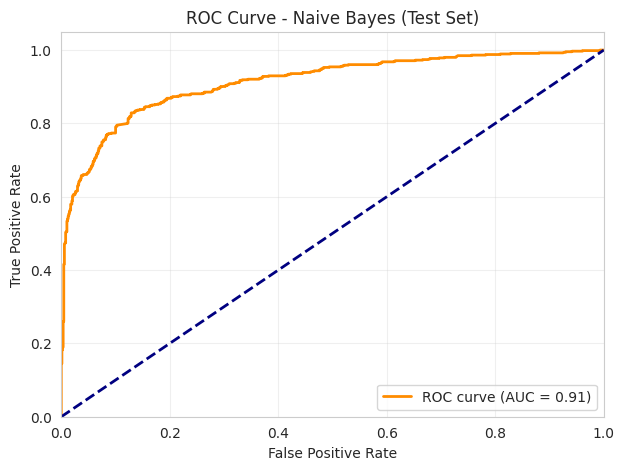

In [ ]:
# Probabilitas prediksi kelas 1 (Bencana)
y_pred_proba = best_nb_model.predict_proba(X_test_nb)[:, 1]

# Hitung ROC curve dan AUC
fpr, tpr, thresholds = roc_curve(y_test_nb, y_pred_proba)
auc_score = roc_auc_score(y_test_nb, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes (Test Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

##Model Interpretability

###Analisis Kesalahan Model

In [ ]:
# ----------------------------------------------------
# Make Predictions on the ENTIRE dataset
# ----------------------------------------------------

df['predicted_label_lr'] = best_model_lr.predict(X_selected_lr)
df['predicted_label_nb'] = best_nb_model.predict(X_selected_nb) # Corrected variable name


# ----------------------------------------------------
# Extract Locations for predicted DISASTER tweets on the ENTIRE dataset
# ----------------------------------------------------

# Function to extract location (copying the one from the previous working cell)
def extract_location_for_df(text, nlp_model):
    doc = nlp_model(text)
    locations_ner = [ent.text for ent in doc.ents if ent.label_ in ['GPE', 'LOC']]
    if locations_ner: return ", ".join(sorted(list(set(locations_ner))))
    locations_pos = [token.text for token in doc if token.pos_ == 'PROPN']
    if locations_pos: return ", ".join(sorted(list(set(locations_pos))))
    return "Unknown"


# Apply location extraction conditionally based on the prediction for each model
df['extracted_location_lr'] = df.apply(lambda row: extract_location_for_df(row['text'], nlp) if row['predicted_label_lr'] == 1 else 'Unknown', axis=1) # Use nlp, not nlp_spacy
df['extracted_location_nb'] = df.apply(lambda row: extract_location_for_df(row['text'], nlp) if row['predicted_label_nb'] == 1 else 'Unknown', axis=1) # Use nlp, not nlp_spacy


# ----------------------------------------------------
# Rename the actual label column for clarity
# ----------------------------------------------------
df.rename(columns={'target':'actual_label'}, inplace=True)

####Banding prediksi model

In [ ]:
banding = ['text', 'actual_label', 'predicted_label_lr', 'predicted_label_nb']
df_banding = df[banding]
df_banding.sample(10)

,text,actual_label,predicted_label_lr,predicted_label_nb
1615,@BehindAShield @Wars_Goddess Sweet Lord. (I c...,0,0,0
513,TV program I saw said US air plane flew to ura...,1,1,1
2164,Malaysia Airlines Flight 370 that Disappeared ...,1,1,1
3845,@kelworldpeace @TAXSTONE yoga flames!,0,0,0
1589,Gulfport Energy - All-In Realizations Fall Off...,0,0,0
2144,No two cases don't constitute an epidemic. htt...,1,1,1
1348,@MoFanon ?? your last retweet you would think ...,0,0,1
6067,150-Foot Sinkhole Opens In Lowndes County Resi...,1,1,1
4771,Lightning strike in the distance via /r/pics h...,1,1,1
4096,@Flow397 Coming atcha from Boston. Had golfbal...,0,0,0


In [ ]:
# Filter baris di mana prediksi LR atau NB tidak sama dengan actual label
df_mismatch = df_banding[
    (df_banding['predicted_label_lr'] != df_banding['actual_label']) |
    (df_banding['predicted_label_nb'] != df_banding['actual_label'])
]

# Tampilkan hasil
df_mismatch.sample(10)

,text,actual_label,predicted_label_lr,predicted_label_nb
7167,#WorldWatchesFerguson #Florida @GovJayNixon @c...,1,1,0
2880,Thought it was a drought @_ASHJ? http://t.co/V...,1,1,0
3894,Fylde Building set to be flattened: One of Pre...,0,1,1
577,Jacksonville Busines FedEx stops shipping pote...,1,1,0
2000,@BradleyBrad47 the saw is fast af and does gre...,0,1,0
5031,@Lolly_Knickers It's a mudslide. \nIt's like c...,1,1,0
5136,Finnish ministers: Fennovoima nuclear reactor ...,0,0,1
6565,Dying with debt can be costly for survivors,0,1,1
4068,Campsite recommendations \nToilets /shower \nP...,1,0,0
5150,A 17 year Boy Scout created a mini nuclear rea...,0,1,0


####Prediksi ablaze

In [ ]:
# Ambil index baris di df_banding yang mengandung kata "ablaze"
ablaze_index = df_banding[df_banding['text'].str.contains('ablaze', case=False, na=False)].index

# Gunakan index tersebut untuk ambil baris dari df
df_ablaze = df.loc[ablaze_index]

# Tampilkan hasil
df_ablaze = df_ablaze[['text', 'actual_label', 'predicted_label_lr', 'predicted_label_nb']]
df_ablaze.sample(10)

,text,actual_label,predicted_label_lr,predicted_label_nb
34,Crying out for more! Set me ablaze,0,1,1
62,Rene Ablaze &amp; Jacinta - Secret 2k13 (Falle...,0,0,0
35,On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0,0,0
64,#NowPlaying: Rene Ablaze &amp; Ian Buff - Magn...,0,0,0
56,TRUCK ABLAZE : R21. VOORTREKKER AVE. OUTSIDE O...,1,1,0
31,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1,1,1
46,How the West was burned: Thousands of wildfire...,1,1,1
55,#Kurds trampling on Turkmen flag later set it ...,1,1,1
57,Set our hearts ablaze and every city was a gif...,0,0,0
50,Deputies: Man shot before Brighton home set ab...,1,1,1


In [ ]:
# Filter df_mismatch untuk baris yang mengandung kata 'ablaze'
df_mismatch_ablaze = df_mismatch[df_mismatch['text'].str.contains('ablaze', case=False, na=False)]

# Tampilkan hasil
df_mismatch_ablaze

,text,actual_label,predicted_label_lr,predicted_label_nb
34,Crying out for more! Set me ablaze,0,1,1
41,on the outside you're ablaze and alive\nbut yo...,0,0,1
56,TRUCK ABLAZE : R21. VOORTREKKER AVE. OUTSIDE O...,1,1,0
61,Progressive greetings!\n\nIn about a month stu...,0,0,1


In [ ]:
# Filter tweet yang mengandung kata 'ablaze'
mask_ablaze = df['text'].str.contains('ablaze', case=False, na=False)

# Untuk Logistic Regression: hanya jika prediksi ≠ label aktual
df_ablaze_lr = df.loc[
    mask_ablaze & (df['actual_label'] != df['predicted_label_lr']),
    ['text', 'actual_label', 'predicted_label_lr']
]

# Untuk Naive Bayes: hanya jika prediksi ≠ label aktual
df_ablaze_nb = df.loc[
    mask_ablaze & (df['actual_label'] != df['predicted_label_nb']),
    ['text', 'actual_label', 'predicted_label_nb']
]

In [ ]:
print(f'Banyaknya kesalahan: {len(df_ablaze_lr)}')
df_ablaze_lr

Banyaknya kesalahan: 1


,text,actual_label,predicted_label_lr
34,Crying out for more! Set me ablaze,0,1


In [ ]:
print(f'Banyaknya kesalahan: {len(df_ablaze_nb)}')
df_ablaze_nb

Banyaknya kesalahan: 4


,text,actual_label,predicted_label_nb
34,Crying out for more! Set me ablaze,0,1
41,on the outside you're ablaze and alive\nbut yo...,0,1
56,TRUCK ABLAZE : R21. VOORTREKKER AVE. OUTSIDE O...,1,0
61,Progressive greetings!\n\nIn about a month stu...,0,1


###Lokasi

In [ ]:
# ----------------------------------------------------
# Display the relevant columns of the updated DataFrame
# ----------------------------------------------------
print("\n--- DataFrame with Predictions and Extracted Locations (Entire Dataset) ---")
# Select and display only the relevant columns
display_columns = ['text', 'extracted_location_lr', 'extracted_location_nb']
# display(df[display_columns].head(20))
# Simpan kolom-kolom relevan ke dalam df_lokasi
df_lokasi = df[display_columns]

# (Opsional) tampilkan beberapa baris awal untuk konfirmasi
df_lokasi.sample(10)


--- DataFrame with Predictions and Extracted Locations (Entire Dataset) ---


,text,extracted_location_lr,extracted_location_nb
6160,@SoonerMagic_ I mean I'm a fan but I don't nee...,Unknown,Unknown
586,FedEx not willing to transport research specim...,FedEx,FedEx
2698,Ignition Knock (Detonation) Sensor-Senso Stand...,Unknown,Unknown
4447,Sydney hostage crisis has now been recovered f...,"AirAsia, Sydney","AirAsia, Sydney"
2545,Plot\nIn the futurea totalitarian government e...,Unknown,Unknown
7544,Wrecked an hour on YouTube with @julian_lage @...,Unknown,Unknown
3954,@adorableappple No reported flooding po in the...,Ten-4,Unknown
3916,Homecoming Queen Killed on Way Home from the P...,"Flood, Prom, Queen, Waters, Way","Flood, Prom, Queen, Waters, Way"
1630,ÛÏ@TheHighFessions: 'My friend came to school...,Unknown,Unknown
273,ohH NO FUKURODANI DIDN'T SURVIVE THE APOCALYPS...,Unknown,"APOCALYPSE, BOKUTO, FUKURODANI, HORRIBLE, ohH"


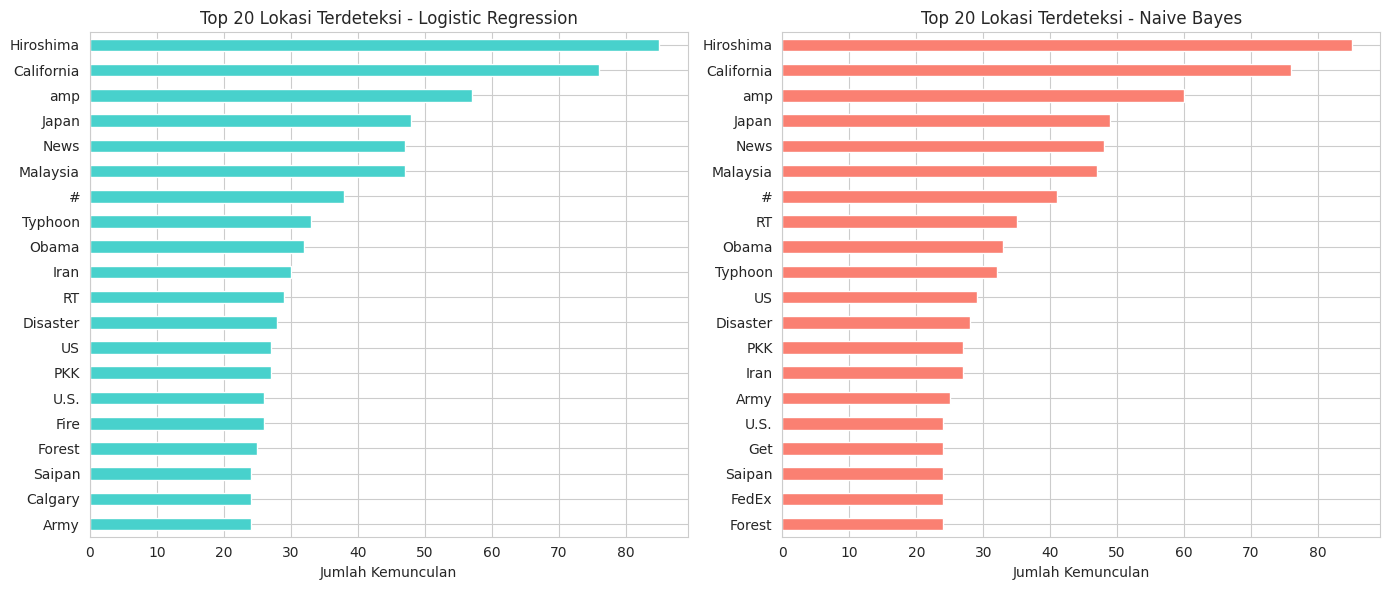

In [ ]:
# Gabungkan semua lokasi yang berhasil diprediksi untuk masing-masing model
locations_lr = df_lokasi['extracted_location_lr'][df_lokasi['extracted_location_lr'] != 'Unknown'].str.split(', ')
locations_nb = df_lokasi['extracted_location_nb'][df_lokasi['extracted_location_nb'] != 'Unknown'].str.split(', ')

# Flatten list dan hitung frekuensi
flat_lr = pd.Series([loc.strip() for sublist in locations_lr for loc in sublist])
flat_nb = pd.Series([loc.strip() for sublist in locations_nb for loc in sublist])

top20_lr = flat_lr.value_counts().head(20)
top20_nb = flat_nb.value_counts().head(20)

# Plotting
plt.figure(figsize=(14, 6))

# Barplot untuk Logistic Regression
plt.subplot(1, 2, 1)
top20_lr.plot(kind='barh', color='mediumturquoise')
plt.gca().invert_yaxis()
plt.title("Top 20 Lokasi Terdeteksi - Logistic Regression")
plt.xlabel("Jumlah Kemunculan")

# Barplot untuk Naive Bayes
plt.subplot(1, 2, 2)
top20_nb.plot(kind='barh', color='salmon')
plt.gca().invert_yaxis()
plt.title("Top 20 Lokasi Terdeteksi - Naive Bayes")
plt.xlabel("Jumlah Kemunculan")

plt.tight_layout()
plt.show()

###Deteksi Event, Date, Time

In [ ]:
# Fungsi untuk mendeteksi EVENT, DATE, TIME
def extract_event_and_time(text):
    doc = nlp(text)
    events = [ent.text for ent in doc.ents if ent.label_ == 'EVENT']
    dates  = [ent.text for ent in doc.ents if ent.label_ == 'DATE']
    times  = [ent.text for ent in doc.ents if ent.label_ == 'TIME']
    combined = []
    if events:
        combined.append(f"EVENT: {', '.join(events)}")
    if dates:
        combined.append(f"DATE: {', '.join(dates)}")
    if times:
        combined.append(f"TIME: {', '.join(times)}")
    return " | ".join(combined) if combined else "Unknown"

In [ ]:
# ====================================================
# Buat kolom event_time detection dari masing-masing model
# ====================================================

df['extracted_event_time_lr'] = [
    extract_event_and_time(text) if pred == 1 else "Unknown"
    for text, pred in zip(df['text'], df['predicted_label_lr'])
]

df['extracted_event_time_nb'] = [
    extract_event_and_time(text) if pred == 1 else "Unknown"
    for text, pred in zip(df['text'], df['predicted_label_nb'])
]

# ====================================================
# Bangun DataFrame final
# ====================================================

df_final = df[['text', 'actual_label',
               'predicted_label_lr', 'predicted_label_nb',
               'extracted_location_lr', 'extracted_location_nb',
               'extracted_event_time_lr', 'extracted_event_time_nb']]

# ====================================================
# Tampilkan hasil
# ====================================================
print("\n--- DataFrame final dengan lokasi & event_time dari masing-masing model ---")
df_final.head()


--- DataFrame final dengan lokasi & event_time dari masing-masing model ---


,text,actual_label,predicted_label_lr,predicted_label_nb,extracted_location_lr,extracted_location_nb,extracted_event_time_lr,extracted_event_time_nb
0,Our Deeds are the Reason of this #earthquake M...,1,1,1,"ALLAH, Reason","ALLAH, Reason",Unknown,Unknown
1,Forest fire near La Ronge Sask. Canada,1,1,1,Canada,Canada,Unknown,Unknown
2,All residents asked to 'shelter in place' are ...,1,1,1,Unknown,Unknown,Unknown,Unknown
3,"13,000 people receive #wildfires evacuation or...",1,1,1,California,California,Unknown,Unknown
4,Just got sent this photo from Ruby #Alaska as ...,1,1,1,Alaska,Alaska,Unknown,Unknown


####Event

In [ ]:
# Filter rows that contain 'EVENT:' in either 'extracted_event_time_lr' or 'extracted_event_time_nb'
# Use df_final as it contains the extracted_event_time columns
df_event_only = df_final[
    df_final['extracted_event_time_lr'].str.contains("EVENT:", case=False, na=False) |
    df_final['extracted_event_time_nb'].str.contains("EVENT:", case=False, na=False)
]


# Display the relevant columns of the result
print("\n--- Rows where EVENT: was detected in either model's output ---")
display_columns = ['text', 'extracted_event_time_lr', 'extracted_event_time_nb']
display(df_event_only[display_columns].sample(10))


--- Rows where EVENT: was detected in either model's output ---


,text,extracted_event_time_lr,extracted_event_time_nb
3308,The U.S. also flew over each bomb site in Worl...,EVENT: World War II,EVENT: World War II
454,Horrific attack on wife by muslim in Italy htt...,EVENT: LiveLeak #News,EVENT: LiveLeak #News
3367,VIETNAM WAR PATCH US 71st EVACUATION HOSPITAL ...,EVENT: VIETNAM WAR,EVENT: VIETNAM WAR
5286,A Mad Catastrophe : The Outbreak of World War ...,EVENT: World War I,EVENT: World War I
5107,The president spoke of Kennedy's diplomacy to ...,EVENT: the Cold War,EVENT: the Cold War
3020,DUST IN THE WIND: @82ndABNDIV paratroopers mov...,EVENT: Operation Fury,EVENT: Operation Fury
2195,Debris confirmed from MH370; relatives hope fo...,EVENT: @Reuters #Video,EVENT: @Reuters #Video
3481,A Time-Lapse Map of Every Nuclear Explosion Si...,EVENT: Every Nuclear Explosion Since | DATE: 1945,EVENT: Every Nuclear Explosion Since | DATE: 1945
156,Pilot Dies In Plane Crash At Car Festival http...,EVENT: Car Festival,EVENT: Car Festival
4030,View of smoke column rising above the south en...,EVENT: Forest Road 1,EVENT: Forest Road 1


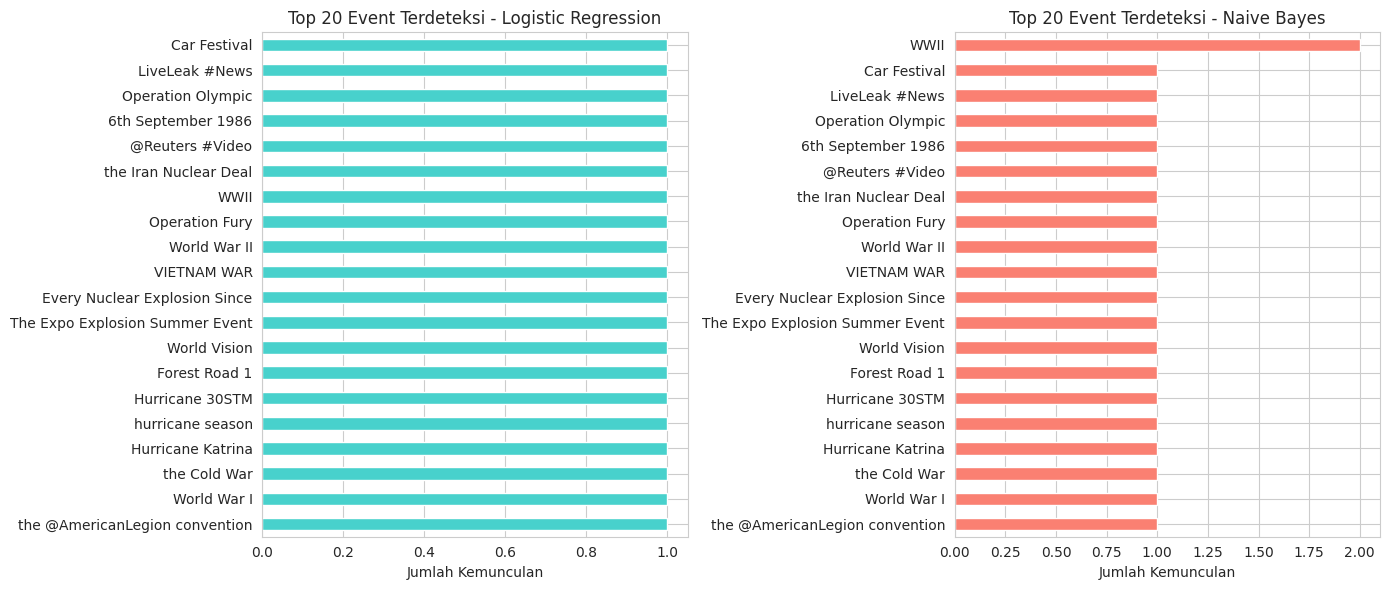

In [ ]:
# Ambil hanya bagian 'EVENT: ...' dari masing-masing kolom
def extract_event_text(cell):
    if pd.isna(cell):
        return []
    return [seg.replace("EVENT: ", "").strip() for seg in cell.split(" | ") if seg.startswith("EVENT:")]

# Ubah ke list of events
events_lr = df_event_only['extracted_event_time_lr'].apply(extract_event_text)
events_nb = df_event_only['extracted_event_time_nb'].apply(extract_event_text)

# Flatten dan hitung frekuensi
flat_events_lr = pd.Series([event for sublist in events_lr for event in sublist])
flat_events_nb = pd.Series([event for sublist in events_nb for event in sublist])

top20_events_lr = flat_events_lr.value_counts().head(20)
top20_events_nb = flat_events_nb.value_counts().head(20)

# Plot
plt.figure(figsize=(14, 6))

# Plot untuk Logistic Regression
plt.subplot(1, 2, 1)
top20_events_lr.plot(kind='barh', color='mediumturquoise')
plt.gca().invert_yaxis()
plt.title("Top 20 Event Terdeteksi - Logistic Regression")
plt.xlabel("Jumlah Kemunculan")

# Plot untuk Naive Bayes
plt.subplot(1, 2, 2)
top20_events_nb.plot(kind='barh', color='salmon')
plt.gca().invert_yaxis()
plt.title("Top 20 Event Terdeteksi - Naive Bayes")
plt.xlabel("Jumlah Kemunculan")

plt.tight_layout()
plt.show()


####Date

In [ ]:
# Filter rows that contain 'EVENT:' in either 'extracted_event_time_lr' or 'extracted_event_time_nb'
# Use df_final as it contains the extracted_event_time columns
df_date_only = df_final[
    df_final['extracted_event_time_lr'].str.contains("DATE:", case=False, na=False) |
    df_final['extracted_event_time_nb'].str.contains("DATE:", case=False, na=False)
]


# Display the relevant columns of the result
print("\n--- Rows where DATE: was detected in either model's output ---")
display_columns = ['text', 'extracted_event_time_lr', 'extracted_event_time_nb']
display(df_date_only[display_columns].sample(10))


--- Rows where DATE: was detected in either model's output ---


,text,extracted_event_time_lr,extracted_event_time_nb
929,On #ThisDayInHistory in 1862 Confederate ship ...,DATE: 1862,DATE: 1862
5546,@myrtlegroggins &lt;gasp!&gt; I forgot Sunday!...,DATE: Sunday,DATE: Sunday
4254,@heebsterrr_ I remember the heat wave the year...,DATE: the year,DATE: the year
4979,Senator 'alarmed' by reports U.S. military fam...,DATE: Wednesday,DATE: Wednesday
1156,Japan on Thursday marks the 70th anniversary o...,DATE: Thursday,DATE: Thursday
3481,A Time-Lapse Map of Every Nuclear Explosion Si...,EVENT: Every Nuclear Explosion Since | DATE: 1945,EVENT: Every Nuclear Explosion Since | DATE: 1945
4355,Governor allows parole for California school b...,DATE: 1976,DATE: 1976
3333,13000 evacuated as California firefighters fig...,DATE: 13000,DATE: 13000
3203,@chrisroth98 @chaselabsports in an emergency s...,DATE: the year,DATE: the year
4224,From recycling to only using non-hazardous che...,Unknown,DATE: 1916


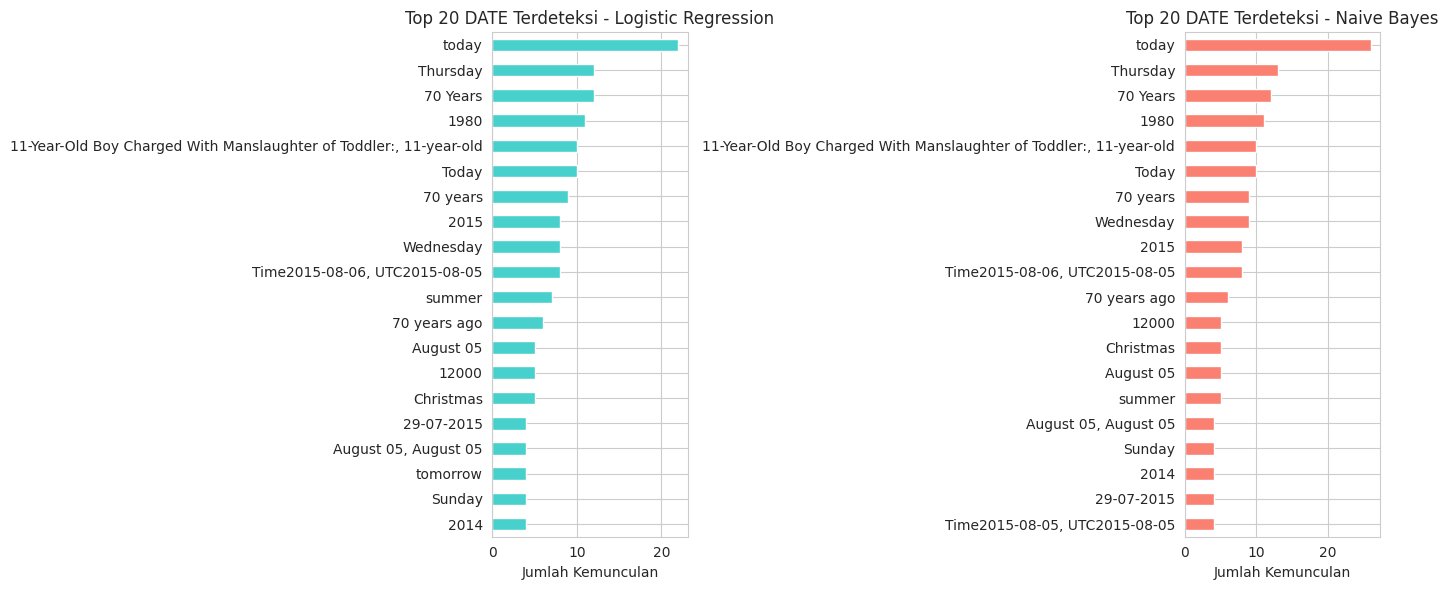

In [ ]:
# Fungsi untuk mengekstrak nilai DATE dari string
def extract_date_text(cell):
    if pd.isna(cell):
        return []
    return [seg.replace("DATE: ", "").strip() for seg in cell.split(" | ") if seg.startswith("DATE:")]

# Terapkan ke kolom masing-masing model
dates_lr = df_date_only['extracted_event_time_lr'].apply(extract_date_text)
dates_nb = df_date_only['extracted_event_time_nb'].apply(extract_date_text)

# Flatten list dan hitung jumlah kemunculan
flat_dates_lr = pd.Series([date for sublist in dates_lr for date in sublist])
flat_dates_nb = pd.Series([date for sublist in dates_nb for date in sublist])

top20_dates_lr = flat_dates_lr.value_counts().head(20)
top20_dates_nb = flat_dates_nb.value_counts().head(20)

# Plot
plt.figure(figsize=(14, 6))

# Bar chart untuk Logistic Regression
plt.subplot(1, 2, 1)
top20_dates_lr.plot(kind='barh', color='mediumturquoise')
plt.gca().invert_yaxis()
plt.title("Top 20 DATE Terdeteksi - Logistic Regression")
plt.xlabel("Jumlah Kemunculan")

# Bar chart untuk Naive Bayes
plt.subplot(1, 2, 2)
top20_dates_nb.plot(kind='barh', color='salmon')
plt.gca().invert_yaxis()
plt.title("Top 20 DATE Terdeteksi - Naive Bayes")
plt.xlabel("Jumlah Kemunculan")

plt.tight_layout()
plt.show()

####Time

In [ ]:
# Filter rows that contain 'EVENT:' in either 'extracted_event_time_lr' or 'extracted_event_time_nb'
# Use df_final as it contains the extracted_event_time columns
df_time_only = df_final[
    df_final['extracted_event_time_lr'].str.contains("TIME:", case=False, na=False) |
    df_final['extracted_event_time_nb'].str.contains("TIME:", case=False, na=False)
]


# Display the relevant columns of the result
print("\n--- Rows where TIME: was detected in either model's output ---")
display_columns = ['text', 'extracted_event_time_lr', 'extracted_event_time_nb']
display(df_time_only[display_columns].sample(10))


--- Rows where TIME: was detected in either model's output ---


,text,extracted_event_time_lr,extracted_event_time_nb
6738,NWS has issued a Severe Thunderstorm Warning f...,TIME: 10:30 PM,TIME: 10:30 PM
4109,Freak #Boston #hailstorm produces a hailstorm ...,TIME: TONIGHT,TIME: TONIGHT
2411,@stury Note there were no passengers on board ...,TIME: this morning,TIME: this morning
7275,Whirlwind that has lasted for more than an hou...,TIME: more than an hour,TIME: more than an hour
4547,Udhampur terror attack: Militants attack polic...,TIME: tonight,TIME: tonight
5565,Tomorrow's evening commute receives a RED LIGH...,"DATE: Tomorrow | TIME: evening, late evening","DATE: Tomorrow | TIME: evening, late evening"
4556,Udhampur terror attack: Militants attack polic...,TIME: tonight,TIME: tonight
1284,burned 202 calories doing 30 minutes of Walkin...,TIME: 30 minutes,Unknown
7328,Route Complex AM Fire Update (Route Complex Wi...,DATE: Thursday | TIME: Morning,DATE: Thursday | TIME: Morning
4214,I-10 EB at MS line update: Offloading the haza...,TIME: tomorrow AM,TIME: tomorrow AM


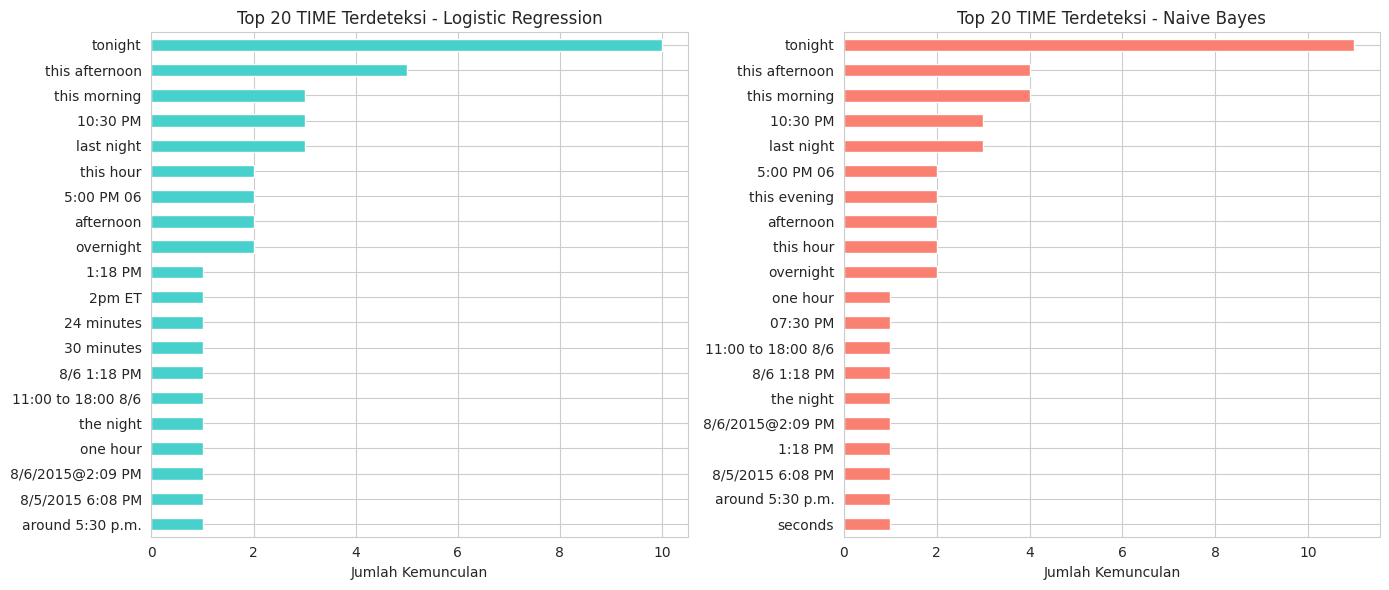

In [ ]:
# Fungsi untuk ekstrak bagian TIME dari string
def extract_time_text(cell):
    if pd.isna(cell):
        return []
    return [seg.replace("TIME: ", "").strip() for seg in cell.split(" | ") if seg.startswith("TIME:")]

# Terapkan ke kolom dari masing-masing model
times_lr = df_time_only['extracted_event_time_lr'].apply(extract_time_text)
times_nb = df_time_only['extracted_event_time_nb'].apply(extract_time_text)

# Flatten list dan hitung jumlah kemunculan
flat_times_lr = pd.Series([time for sublist in times_lr for time in sublist])
flat_times_nb = pd.Series([time for sublist in times_nb for time in sublist])

top20_times_lr = flat_times_lr.value_counts().head(20)
top20_times_nb = flat_times_nb.value_counts().head(20)

# Plotting
plt.figure(figsize=(14, 6))

# Logistic Regression
plt.subplot(1, 2, 1)
top20_times_lr.plot(kind='barh', color='mediumturquoise')
plt.gca().invert_yaxis()
plt.title("Top 20 TIME Terdeteksi - Logistic Regression")
plt.xlabel("Jumlah Kemunculan")

# Naive Bayes
plt.subplot(1, 2, 2)
top20_times_nb.plot(kind='barh', color='salmon')
plt.gca().invert_yaxis()
plt.title("Top 20 TIME Terdeteksi - Naive Bayes")
plt.xlabel("Jumlah Kemunculan")

plt.tight_layout()
plt.show()